Stern-Volmer slope: 1.81510e-03 +/- 9.85463e-05 ns^-1 mM^-1
Intercept: 1.22981e-03 ns^-1


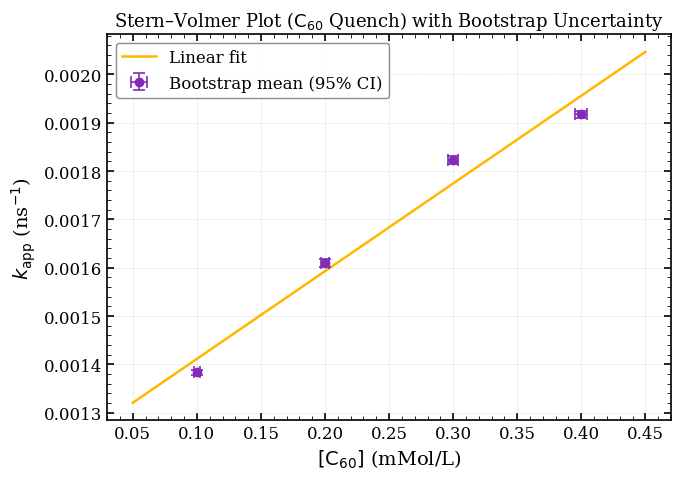


Chi-squared        : 93.612
Reduced Chi-squared: 46.806


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# -----------------------------
# Data
# -----------------------------
concentrations = np.array([0.4, 0.3, 0.2, 0.1])
conc_errors = np.array([4.7e-3, 4.1e-3, 3.4e-3, 2.4e-3])

tau_values = np.array([521.52045, 548.51674, 620.95671, 722.89255])
tau_std_values = np.array([1.04737, 1.16395, 1.59168, 1.58243])

tau_CI_low = np.array([519.44798, 546.21887, 617.85350, 719.87638])
tau_CI_high = np.array([523.61485, 550.78683, 624.19873, 726.01809])

# -----------------------------
# Derived quantities
# -----------------------------
k_app = 1 / tau_values
k_app_CI_low = 1 / tau_CI_high
k_app_CI_high = 1 / tau_CI_low
k_app_CI_width = k_app_CI_high - k_app_CI_low

# -----------------------------
# Linear fit (Stern-Volmer)
# -----------------------------
coeff = np.polyfit(concentrations, k_app, 1)
k_sv_slope = coeff[0]
intercept = coeff[1]

k_sv_slope_error = np.sqrt(
    np.sum((k_app_CI_width / (concentrations.max() - concentrations.min()))**2)
)

print(f"Stern-Volmer slope: {k_sv_slope:.5e} +/- {k_sv_slope_error:.5e} ns^-1 mM^-1")
print(f"Intercept: {intercept:.5e} ns^-1")

# -----------------------------
# Plot styling
# -----------------------------
plt.rcParams.update({
    'font.family': 'serif',
    #'font.serif': ['Times New Roman'],
    'font.size': 13,
    'axes.labelsize': 14,
    'axes.titlesize': 13,
    'legend.fontsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'axes.linewidth': 1.2,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.major.size': 5,
    'xtick.minor.size': 3,
    'ytick.major.size': 5,
    'ytick.minor.size': 3,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
})

fig, ax = plt.subplots(figsize=(7, 5))

# Data points with error bars
ax.errorbar(
    concentrations,
    k_app,
    xerr=conc_errors,
    yerr=[k_app - k_app_CI_low, k_app_CI_high - k_app],
    fmt='o',
    color='#852AB8',
    capsize=4,
    capthick=1.2,
    elinewidth=1.2,
    markersize=6,
    label='Bootstrap mean (95% CI)',
    zorder=5
)

# Linear fit
x_fit = np.linspace(concentrations.min() - 0.05, concentrations.max() + 0.05, 200)
ax.plot(
    x_fit,
    np.polyval(coeff, x_fit),
    color='#FFB700',
    linewidth=1.8,
    label='Linear fit',
    zorder=4
)

# Labels and title
ax.set_xlabel(r'$[\mathrm{C}_{60}]$ (mMol/L)')
ax.set_ylabel(r'$k_\mathrm{app}$ (ns$^{-1}$)')
ax.set_title(r'Stern–Volmer Plot ($\mathrm{C}_{60}$ Quench) with Bootstrap Uncertainty')
ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.4)
ax.set_axisbelow(True)
# Ticks
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

ax.legend(frameon=True, framealpha=0.9, edgecolor='grey')
plt.tight_layout()

# plt.savefig("C60_SternVolmer.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# Chi-squared
# -----------------------------
k_app_sigma = (k_app_CI_high - k_app_CI_low) / 2
k_fit       = np.polyval(coeff, concentrations)
chi2        = np.sum(((k_app - k_fit) / k_app_sigma)**2)
dof         = len(concentrations) - 2
chi2_red    = chi2 / dof

print(f"\nChi-squared        : {chi2:.3f}")
print(f"Reduced Chi-squared: {chi2_red:.3f}")

Stern-Volmer slope: 2.49181e-03 +/- 1.17001e-04 ns^-1 mM^-1
Intercept: 1.18301e-03 ns^-1


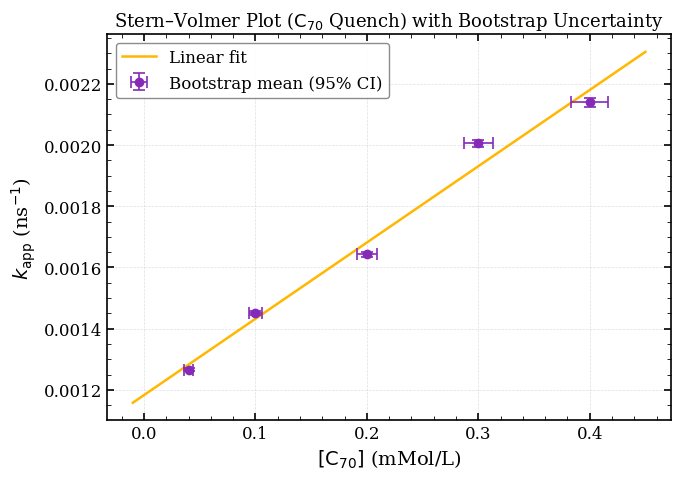


Chi-squared        : 106.044
Reduced Chi-squared: 35.348


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# -----------------------------
# Data
# -----------------------------
concentrations = np.array([0.4, 0.3, 0.2, 0.1, 0.04]) #([0.4, 0.3, 0.2, 0.1, 0.04])
tau_values = np.array([467.37783, 498.67187, 608.80600, 688.46917, 789.54620])
tau_std_values = np.array([1.60444, 1.44686, 1.29290, 1.58258, 1.48348])

tau_CI_low = np.array([464.25428, 495.84387, 606.30114, 685.31760, 786.68959])
tau_CI_high = np.array([470.52153, 501.4426, 611.36303, 691.53833, 792.44233])

conc_err = [1.685e-2, 1.291e-2, 9.11e-3, 5.72e-3, 4.322e-3]

# -----------------------------
# Derived quantities
# -----------------------------
k_app = 1 / tau_values
k_app_CI_low = 1 / tau_CI_high
k_app_CI_high = 1 / tau_CI_low
k_app_CI_width = k_app_CI_high - k_app_CI_low

# -----------------------------
# Linear fit (Stern-Volmer)
# -----------------------------
coeff = np.polyfit(concentrations, k_app, 1)
k_sv_slope = coeff[0]
intercept = coeff[1]

k_sv_slope_error = np.sqrt(
    np.sum((k_app_CI_width / (concentrations.max() - concentrations.min()))**2)
)

print(f"Stern-Volmer slope: {k_sv_slope:.5e} +/- {k_sv_slope_error:.5e} ns^-1 mM^-1")
print(f"Intercept: {intercept:.5e} ns^-1")

# -----------------------------
# Plot styling
# -----------------------------
plt.rcParams.update({
    'font.family': 'serif',
    #'font.serif': ['Times New Roman'],
    'font.size': 13,
    'axes.labelsize': 14,
    'axes.titlesize': 13,
    'legend.fontsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'axes.linewidth': 1.2,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.major.size': 5,
    'xtick.minor.size': 3,
    'ytick.major.size': 5,
    'ytick.minor.size': 3,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
})

fig, ax = plt.subplots(figsize=(7, 5))

# Data points with error bars
ax.errorbar(
    concentrations,
    k_app,
    xerr=conc_err,
    yerr=[k_app - k_app_CI_low, k_app_CI_high - k_app],
    fmt='o',
    color='#852AB8',
    capsize=4,
    capthick=1.2,
    elinewidth=1.2,
    markersize=6,
    label='Bootstrap mean (95% CI)',
    zorder=5
)

# Linear fit
x_fit = np.linspace(concentrations.min() - 0.05, concentrations.max() + 0.05, 200)
ax.plot(
    x_fit,
    np.polyval(coeff, x_fit),
    color='#FFB700',
    linewidth=1.8,
    label='Linear fit',
    zorder=4
)

# Labels and title
ax.set_xlabel(r'$[\mathrm{C}_{70}]$ (mMol/L)')
ax.set_ylabel(r'$k_\mathrm{app}$ (ns$^{-1}$)')
ax.set_title(r'Stern–Volmer Plot ($\mathrm{C}_{70}$ Quench) with Bootstrap Uncertainty')

# Ticks
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.4)
ax.set_axisbelow(True)

ax.legend(frameon=True, framealpha=0.9, edgecolor='grey')
plt.tight_layout()

# plt.savefig("C70_SternVolmer.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# Chi-squared
# -----------------------------
k_app_sigma = (k_app_CI_high - k_app_CI_low) / 2
k_fit       = np.polyval(coeff, concentrations)
chi2        = np.sum(((k_app - k_fit) / k_app_sigma)**2)
dof         = len(concentrations) - 2
chi2_red    = chi2 / dof

print(f"\nChi-squared        : {chi2:.3f}")
print(f"Reduced Chi-squared: {chi2_red:.3f}")

=== Weighted polyfit (covariance matrix) ===
  Ksv (slope)   : 1.17446e-04  ±  2.53324e-06  ns^-1 mM^-1
  k1 (intercept): 1.08002e-03  ±  1.63541e-06  ns^-1

=== Bootstrap cross-check (n=10,000) ===
  Ksv : 1.16029e-04  ±  8.27891e-06  | 95% CI [1.00017e-04, 1.32277e-04]
  k1  : 1.08057e-03  ±  4.95036e-06  | 95% CI [1.07084e-03, 1.09017e-03]


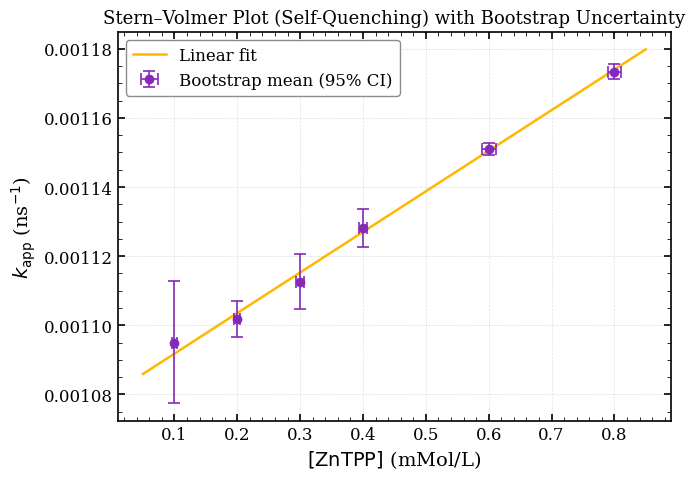


Chi-squared        : 0.453
Reduced Chi-squared: 0.113


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# -----------------------------
# Data
# -----------------------------
concentrations = np.array([0.8, 0.6, 0.4, 0.3, 0.2, 0.1])
tau_values = np.array([852.22356, 868.76250, 886.48941, 898.85662, 907.50005, 913.34809])
tau_std_values = np.array([0.80758, 0.68813, 2.17208, 3.27438, 2.18130, 7.50122])

tau_CI_low  = np.array([850.65059, 867.41159, 882.20551, 892.43311, 903.21945, 898.70783])
tau_CI_high = np.array([853.80531, 870.10510, 890.74130, 905.24706, 911.80480, 928.08607])

conc_err = np.array([0.010, 0.011, 0.007, 0.006, 0.005, 0.004])

# -----------------------------
# Derived quantities
# -----------------------------
k_app         = 1 / tau_values
k_app_SE      = tau_std_values / (tau_values**2)
k_app_CI_low  = 1 / tau_CI_high
k_app_CI_high = 1 / tau_CI_low

# -----------------------------
# Weighted linear fit
# -----------------------------
weights = 1 / k_app_SE
coeff, cov = np.polyfit(concentrations, k_app, 1, w=weights, cov=True)
k_sv_slope     = coeff[0]
intercept      = coeff[1]
k_sv_slope_err = np.sqrt(cov[0, 0])
intercept_err  = np.sqrt(cov[1, 1])

# -----------------------------
# Bootstrap cross-check
# -----------------------------
n_boot = 10_000
rng = np.random.default_rng(42)
boot_slopes     = np.empty(n_boot)
boot_intercepts = np.empty(n_boot)

for i in range(n_boot):
    k_boot = k_app + rng.normal(0, k_app_SE, size=len(k_app))
    c_boot = np.polyfit(concentrations, k_boot, 1)
    boot_slopes[i]     = c_boot[0]
    boot_intercepts[i] = c_boot[1]

boot_slope_std     = np.std(boot_slopes,     ddof=1)
boot_intercept_std = np.std(boot_intercepts, ddof=1)
slope_CI     = np.percentile(boot_slopes,     [2.5, 97.5])
intercept_CI = np.percentile(boot_intercepts, [2.5, 97.5])

# -----------------------------
# Print results
# -----------------------------
print("=== Weighted polyfit (covariance matrix) ===")
print(f"  Ksv (slope)   : {k_sv_slope:.5e}  ±  {k_sv_slope_err:.5e}  ns^-1 mM^-1")
print(f"  k1 (intercept): {intercept:.5e}  ±  {intercept_err:.5e}  ns^-1")

print("\n=== Bootstrap cross-check (n=10,000) ===")
print(f"  Ksv : {np.mean(boot_slopes):.5e}  ±  {boot_slope_std:.5e}  "
      f"| 95% CI [{slope_CI[0]:.5e}, {slope_CI[1]:.5e}]")
print(f"  k1  : {np.mean(boot_intercepts):.5e}  ±  {boot_intercept_std:.5e}  "
      f"| 95% CI [{intercept_CI[0]:.5e}, {intercept_CI[1]:.5e}]")

# -----------------------------
# Plot styling
# -----------------------------
plt.rcParams.update({
    'font.family': 'serif',
    #'font.serif': ['Times New Roman'],
    'font.size': 13,
    'axes.labelsize': 14,
    'axes.titlesize': 13,
    'legend.fontsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'axes.linewidth': 1.2,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.major.size': 5,
    'xtick.minor.size': 3,
    'ytick.major.size': 5,
    'ytick.minor.size': 3,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
})

fig, ax = plt.subplots(figsize=(7, 5))

# Data points with error bars
ax.errorbar(
    concentrations,
    k_app,
    xerr=conc_err,
    yerr=[k_app - k_app_CI_low, k_app_CI_high - k_app],
    fmt='o',
    color='#852AB8',
    capsize=4,
    capthick=1.2,
    elinewidth=1.2,
    markersize=6,
    label='Bootstrap mean (95% CI)',
    zorder=5
)

# Linear fit
x_fit = np.linspace(concentrations.min() - 0.05, concentrations.max() + 0.05, 200)
ax.plot(
    x_fit,
    np.polyval(coeff, x_fit),
    color='#FFB700',
    linewidth=1.8,
    label='Linear fit',
    zorder=4
)
ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.4)
ax.set_axisbelow(True)

# Labels and title
ax.set_xlabel(r'$[\mathrm{ZnTPP}]$ (mMol/L)')
ax.set_ylabel(r'$k_\mathrm{app}$ (ns$^{-1}$)')
ax.set_title(r'Stern–Volmer Plot (Self-Quenching) with Bootstrap Uncertainty')

# Ticks
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

ax.legend(frameon=True, framealpha=0.9, edgecolor='grey')
plt.tight_layout()

# plt.savefig("Self_SternVolmer.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# Chi-squared
# -----------------------------
k_app_sigma = (k_app_CI_high - k_app_CI_low) / 2
k_fit       = np.polyval(coeff, concentrations)
chi2        = np.sum(((k_app - k_fit) / k_app_sigma)**2)
dof         = len(concentrations) - 2
chi2_red    = chi2 / dof

print(f"\nChi-squared        : {chi2:.3f}")
print(f"Reduced Chi-squared: {chi2_red:.3f}")